# 09c · Per-spot pie (scatterpie) spatial maps

Each Visium spot is drawn as a small pie chart of its deconvolved cell-type
composition, over the (dimmed) H&E. Reads the compact `spatial_bundle.h5ad`
(coords + images + per-spot `prop_*`, no expression matrix) pulled from the
peer — **no 4.8 GB h5ad needed**.

Two views:
1. **Coarse (8 slices):** 6 structural types + `Microglia` + `Other immune`.
2. **Myeloid compartment:** the split *within* the immune fraction
   (Microglia / CAM / MDM / cDC1 / Granulocyte / Other), renormalised per spot.

Pass-1 fractions (18 types; immune compartment over-assigned — see `09b`).
Swap `BUNDLE` to the pruned run's bundle when that finishes to compare.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd
from pathlib import Path
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D

ROOT = Path.cwd()
while not (ROOT / 'data').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
BUNDLE = ROOT / 'data' / 'external' / 'deconv_reference' / 'spatial_bundle.h5ad'
FIG = ROOT / 'results' / 'figures' / 'manuscript'; FIG.mkdir(parents=True, exist_ok=True)

a = sc.read_h5ad(BUNDLE)
SAMPLE_KEY, TREATMENT_KEY = 'sample_id', 'treatment'
prop = a.obs[[c for c in a.obs.columns if c.startswith('prop_')]].copy()
prop.columns = [c[len('prop_'):] for c in prop.columns]
print(a.n_obs, 'spots |', a.obs[SAMPLE_KEY].nunique(), 'samples')
print('treatments:', a.obs[TREATMENT_KEY].value_counts().to_dict())
prop.columns.tolist()

25660 spots | 10 samples
treatments: {'PBS': 15107, 'BRICHOS': 7596, 'WT': 2957}


['Astrocytes',
 'Ependymal',
 'MYE:CAM',
 'MYE:CD4 Th17',
 'MYE:CD8 TRM',
 'MYE:Granulocyte',
 'MYE:MAIT',
 'MYE:MDM',
 'MYE:Microglia',
 'MYE:NK',
 'MYE:Plamablasts',
 'MYE:TEx',
 'MYE:Treg',
 'MYE:cDC1',
 'Neurons',
 'Oligos',
 'PeripheralGlia',
 'Vascular']

## 1 · Category groupings + colours

In [2]:
STRUCT = ['Neurons','Astrocytes','Oligos','Ependymal','Vascular','PeripheralGlia']
MYE = [c for c in prop.columns if c.startswith('MYE:')]

# ---- coarse 8-category composition (rows sum to 1) ----
coarse = pd.DataFrame(index=prop.index)
for s in STRUCT:
    coarse[s] = prop[s] if s in prop.columns else 0.0
coarse['Microglia']    = prop.get('MYE:Microglia', 0.0)
coarse['Other immune'] = prop[[c for c in MYE if c != 'MYE:Microglia']].sum(axis=1)
COARSE_COLORS = {
    'Neurons':'#6699CC','Astrocytes':'#66C2A5','Oligos':'#B3B3B3','Ependymal':'#FFD92F',
    'Vascular':'#A6761D','PeripheralGlia':'#E78AC3','Microglia':'#E41A1C','Other immune':'#984EA3'}
COARSE_CATS = list(COARSE_COLORS)

# ---- myeloid-compartment split (renormalised within immune) ----
MYE_KEEP = ['MYE:Microglia','MYE:CAM','MYE:MDM','MYE:cDC1','MYE:Granulocyte']
myo = pd.DataFrame(index=prop.index)
for c in MYE_KEEP:
    myo[c.replace('MYE:','')] = prop.get(c, 0.0)
myo['Other'] = prop[[c for c in MYE if c not in MYE_KEEP]].sum(axis=1)
mye_tot = prop[MYE].sum(axis=1)
myo = myo.div(mye_tot.replace(0, np.nan), axis=0)   # within-immune fractions
MYO_COLORS = {'Microglia':'#E41A1C','CAM':'#377EB8','MDM':'#4DAF4A','cDC1':'#FF7F00',
              'Granulocyte':'#A65628','Other':'#999999'}
MYO_CATS = list(MYO_COLORS)
print('coarse cats:', COARSE_CATS)
print('myeloid cats:', MYO_CATS)

coarse cats: ['Neurons', 'Astrocytes', 'Oligos', 'Ependymal', 'Vascular', 'PeripheralGlia', 'Microglia', 'Other immune']
myeloid cats: ['Microglia', 'CAM', 'MDM', 'cDC1', 'Granulocyte', 'Other']


## 2 · Scatterpie helper

In [3]:
def scatterpie(ax, x, y, fracs, colors, radius):
    """Draw one small pie per (x,y). fracs: (n, k) rows sum to ~1."""
    fracs = np.nan_to_num(np.asarray(fracs, float))
    rs = fracs.sum(1, keepdims=True); rs[rs == 0] = 1
    fracs = fracs / rs
    ang = fracs * 360.0
    start = np.zeros(len(x))
    patches, facecolors = [], []
    for j in range(fracs.shape[1]):
        t1, t2 = start, start + ang[:, j]
        for i in range(len(x)):
            if ang[i, j] > 0.5:                      # skip invisible slivers
                patches.append(Wedge((x[i], y[i]), radius, t1[i], t2[i]))
                facecolors.append(colors[j])
        start = t2
    ax.add_collection(PatchCollection(patches, facecolors=facecolors,
                                      edgecolors='none', antialiased=True))

def pie_map(sample, comp, cats, colmap, radius_scale=0.95, img_alpha=0.55, ax=None):
    m = a.obs[SAMPLE_KEY] == sample
    sp = a.uns['spatial'][sample]
    sf = sp['scalefactors']['tissue_hires_scalef']
    r = 0.5 * sp['scalefactors']['spot_diameter_fullres'] * sf * radius_scale
    xy = a.obsm['spatial'][m.values] * sf
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(sp['images']['hires'], origin='upper', alpha=img_alpha)
    scatterpie(ax, xy[:, 0], xy[:, 1], comp.loc[m.values, cats].values,
               [colmap[c] for c in cats], r)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_visible(False)
    return ax

def legend_handles(colmap):
    return [Line2D([0],[0], marker='o', color='none', markerfacecolor=c,
                   markersize=9, label=k) for k,c in colmap.items()]

## 3 · Coarse pies (8 categories) — per treatment
_Building ~2.5k pies/sample takes a few seconds each._

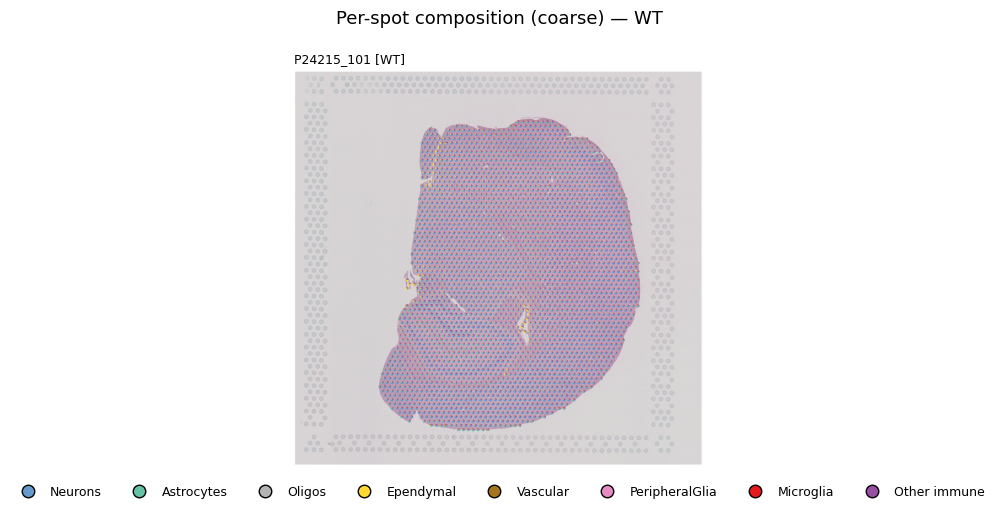

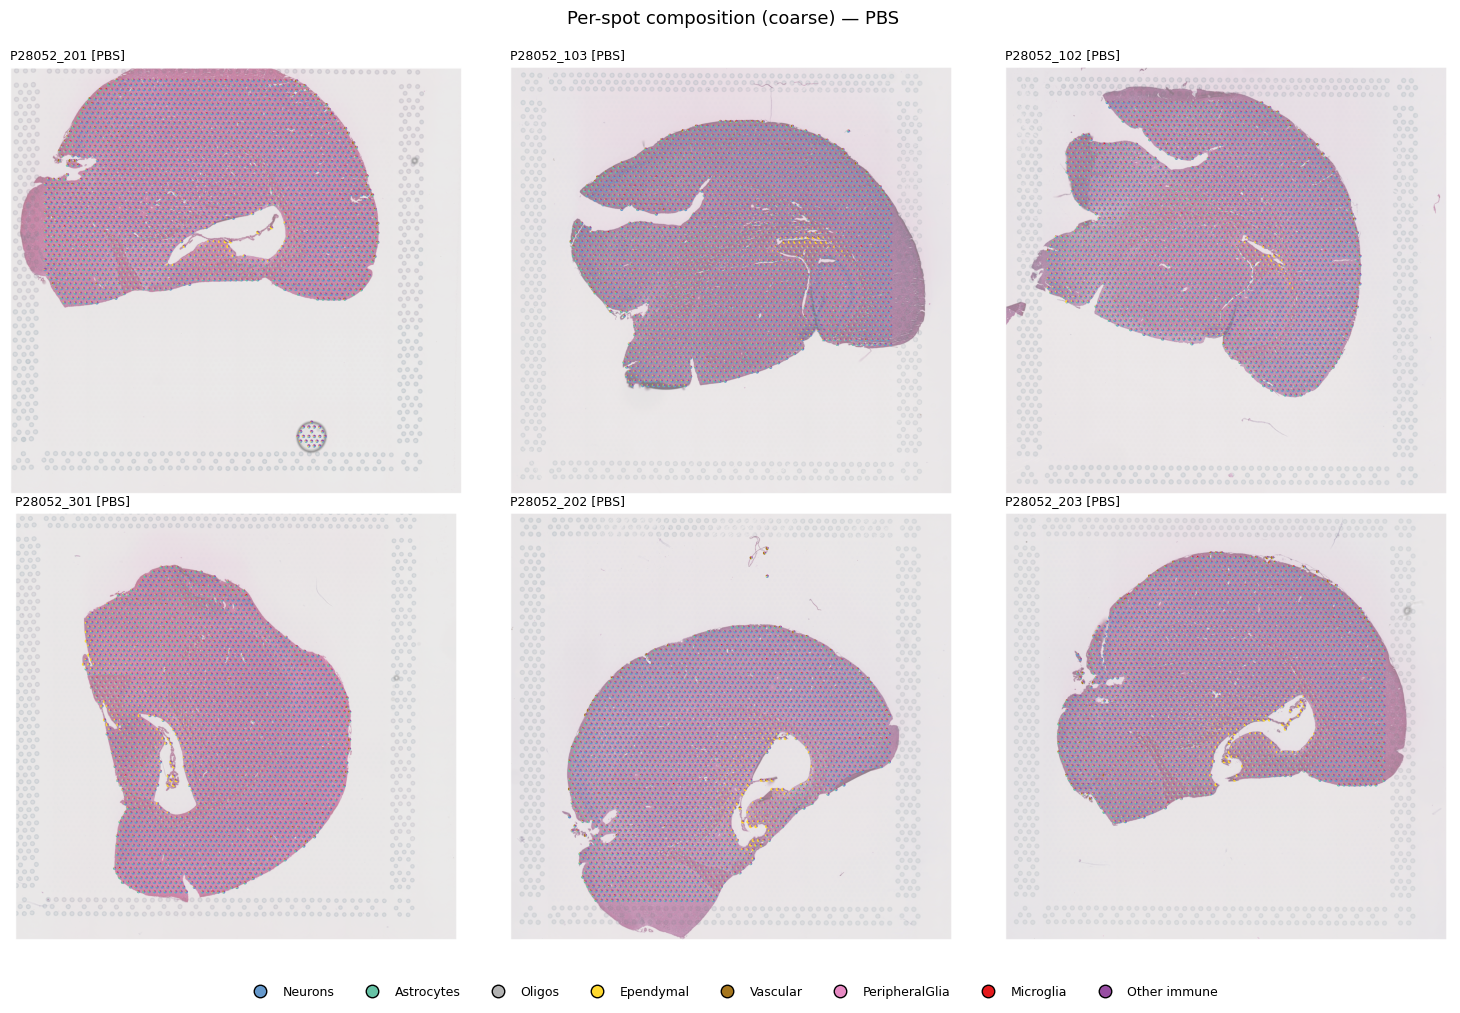

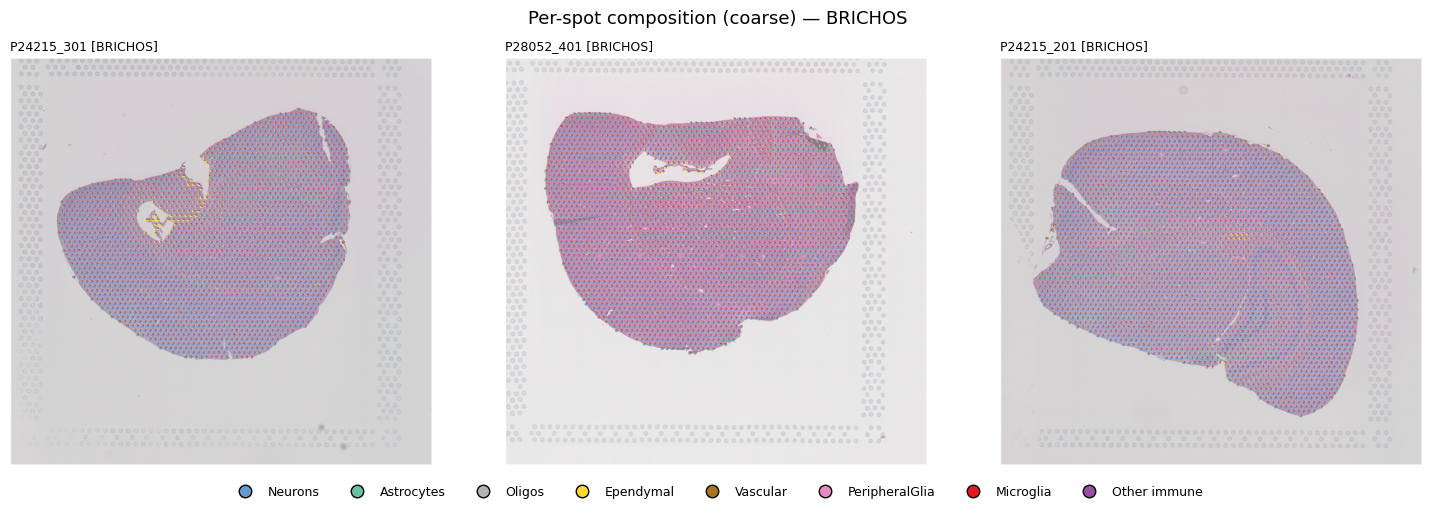

In [4]:
order = ['WT','PBS','BRICHOS']
for treat in order:
    samples = a.obs.loc[a.obs[TREATMENT_KEY]==treat, SAMPLE_KEY].unique()
    if len(samples)==0: continue
    n=len(samples); ncol=min(n,3); nrow=int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), squeeze=False)
    for ax, s in zip(np.ravel(axes), samples):
        pie_map(s, coarse, COARSE_CATS, COARSE_COLORS, ax=ax)
        ax.set_title(f'{s} [{treat}]', fontsize=9, loc='left')
    for ax in np.ravel(axes)[len(samples):]: ax.axis('off')
    fig.legend(handles=legend_handles(COARSE_COLORS), loc='lower center',
               ncol=8, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f'Per-spot composition (coarse) — {treat}', fontsize=13)
    fig.tight_layout(rect=[0,0.03,1,0.98])
    fig.savefig(FIG / f'deconv_pie_coarse_{treat}.png', dpi=180, bbox_inches='tight')
    plt.show()

## 4 · Myeloid-compartment pies — per treatment
Split *within* the immune fraction (renormalised). Spots with negligible immune signal show faint/empty.

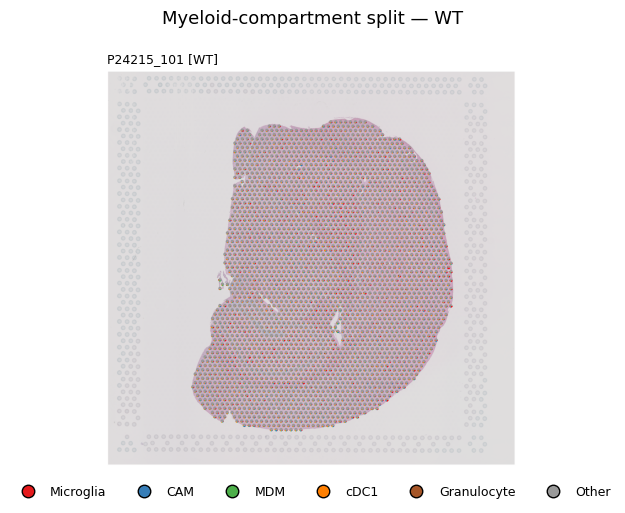

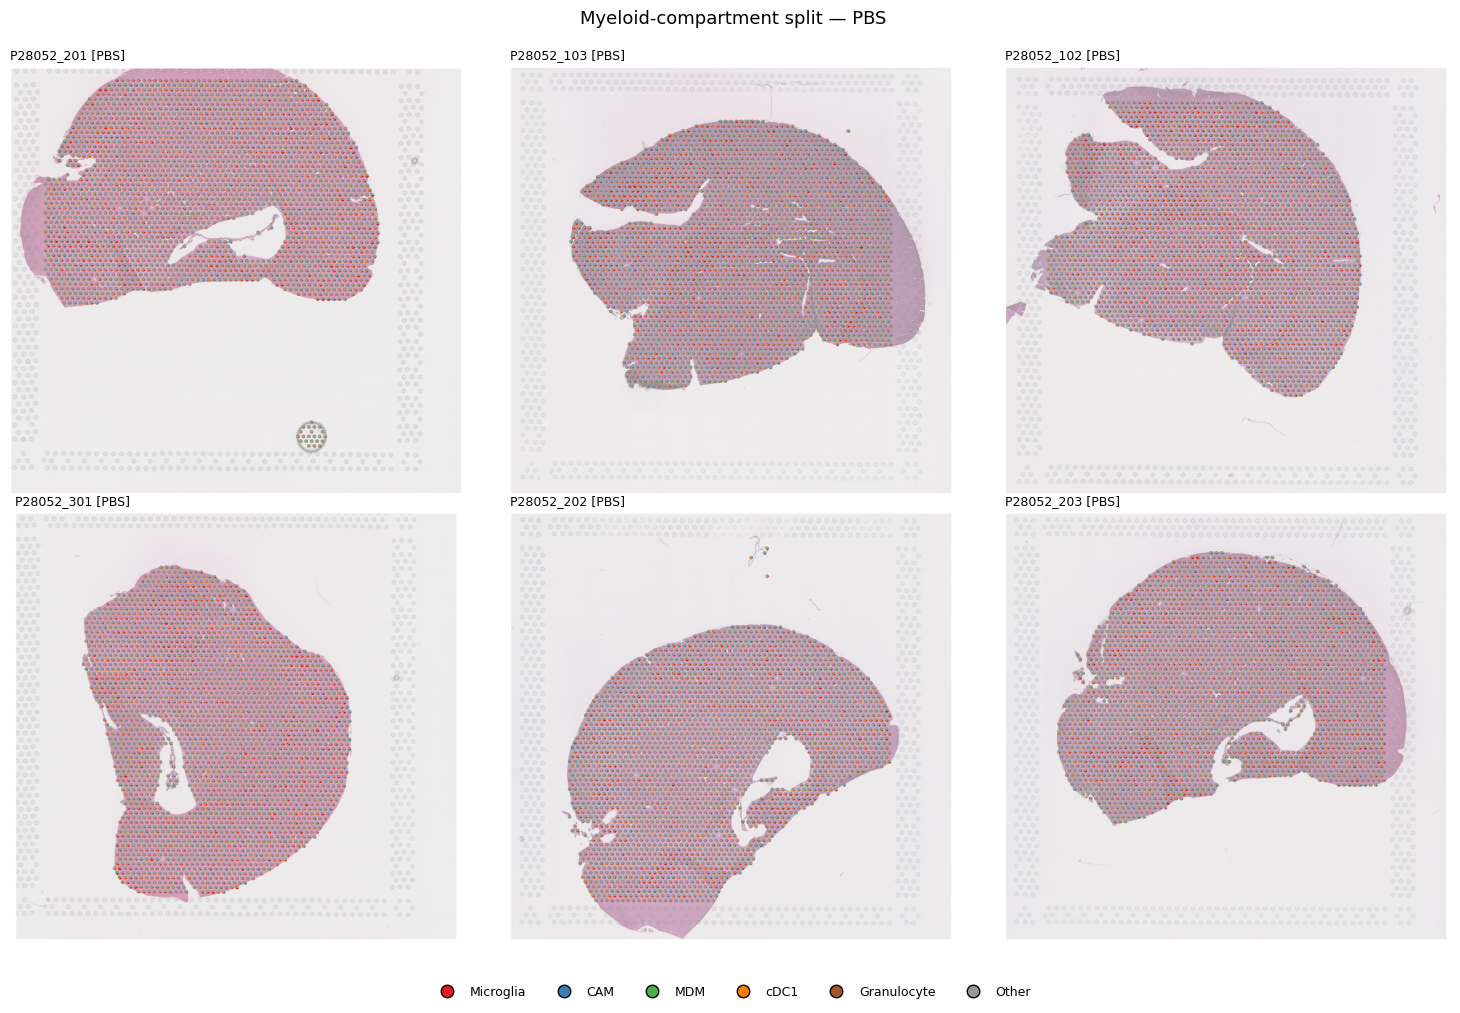

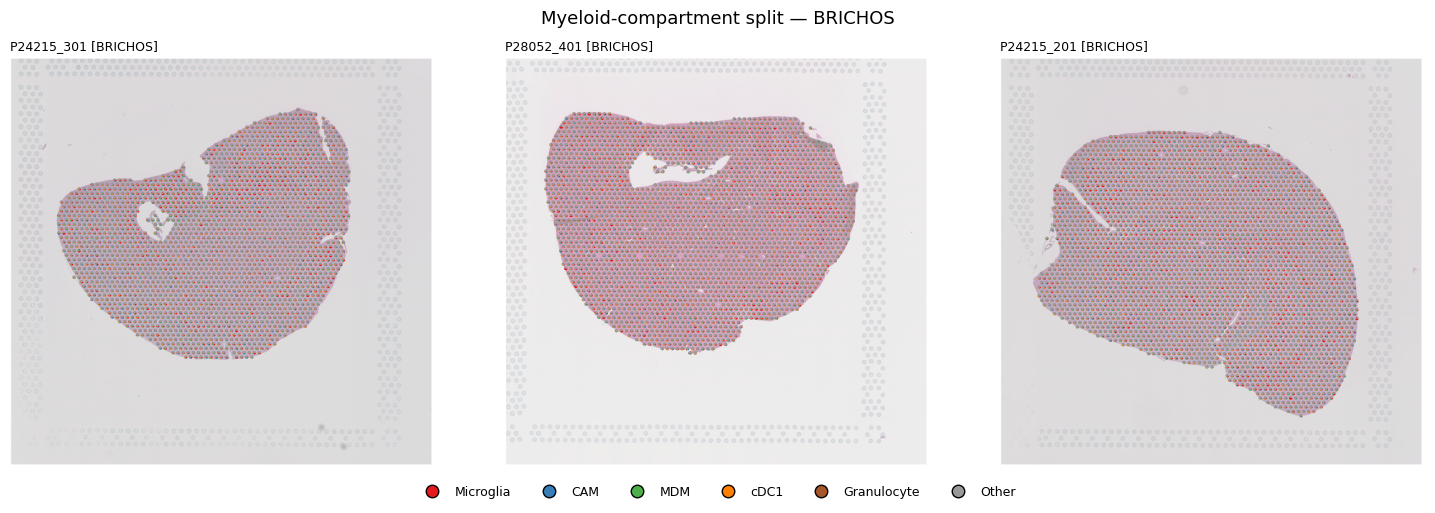

In [5]:
for treat in order:
    samples = a.obs.loc[a.obs[TREATMENT_KEY]==treat, SAMPLE_KEY].unique()
    if len(samples)==0: continue
    n=len(samples); ncol=min(n,3); nrow=int(np.ceil(n/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), squeeze=False)
    for ax, s in zip(np.ravel(axes), samples):
        pie_map(s, myo, MYO_CATS, MYO_COLORS, radius_scale=1.05, img_alpha=0.45, ax=ax)
        ax.set_title(f'{s} [{treat}]', fontsize=9, loc='left')
    for ax in np.ravel(axes)[len(samples):]: ax.axis('off')
    fig.legend(handles=legend_handles(MYO_COLORS), loc='lower center',
               ncol=6, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(f'Myeloid-compartment split — {treat}', fontsize=13)
    fig.tight_layout(rect=[0,0.03,1,0.98])
    fig.savefig(FIG / f'deconv_pie_myeloid_{treat}.png', dpi=180, bbox_inches='tight')
    plt.show()

## 5 · Single-sample zoom (detail)
Pick any sample for a larger, more legible view.

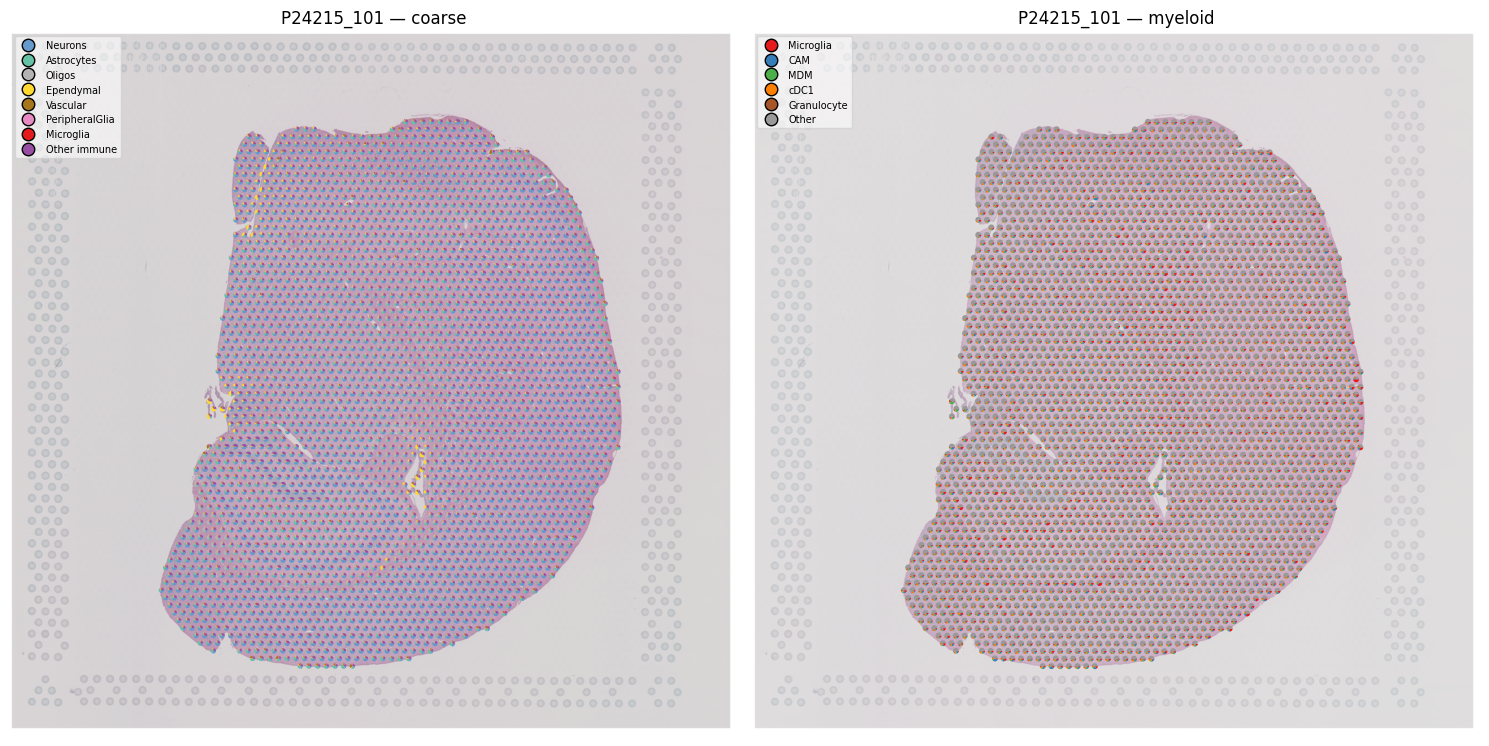

In [6]:
s = a.obs[SAMPLE_KEY].value_counts().index[0]   # busiest section
fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
pie_map(s, coarse, COARSE_CATS, COARSE_COLORS, ax=axes[0]); axes[0].set_title(f'{s} — coarse')
pie_map(s, myo, MYO_CATS, MYO_COLORS, radius_scale=1.05, img_alpha=0.45, ax=axes[1]); axes[1].set_title(f'{s} — myeloid')
axes[0].legend(handles=legend_handles(COARSE_COLORS), loc='upper left', fontsize=7, framealpha=.6)
axes[1].legend(handles=legend_handles(MYO_COLORS), loc='upper left', fontsize=7, framealpha=.6)
fig.tight_layout(); fig.savefig(FIG / f'deconv_pie_zoom_{s}.png', dpi=180, bbox_inches='tight'); plt.show()

## Notes
- Pies visualise *proportions*, not absolute cell counts; spot totals are normalised to 1 (coarse) or to the immune fraction (myeloid).
- Immune slices are **over-assigned in pass 1** — read `Microglia` and `CAM` as the credible myeloid signal; treat the `Other immune` wedge as an upper bound. Re-point `BUNDLE` at the pruned bundle to see the cleaned split.
- To speed things up or de-clutter, raise the sliver threshold in `scatterpie` or plot fewer samples.